In [12]:
from learn_to_infer import Worker
from bandit.task import SwitchingBandit
import pandas as pd
from tqdm import tqdm
import numpy as np
from bandit.fit_model import fit_model_inf_simple  
from data.load_and_process_data import convert_mat_to_dataframe
from scipy.stats import spearmanr
from scipy.io import loadmat
import torch
h_opt = loadmat('/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/data/h_opt.mat')['h_opt'].squeeze()
pcorr_sub_all = loadmat('/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/data/pcor_sub_all.mat')['pcor_sub_all']

In [13]:
# stim = reward of 1st arm in bandit task and outcome of category task
trials_df = convert_mat_to_dataframe()
trials_df.head()

,samp,subj,cond,trlnum,bmstate,stim,resp,rprv,efac,h,alpha,omega,tau
0,sample2,2,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0.76, 0.45999999999999996, -0.26, -0.12, 0.86...","[1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, ...","[2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, ...",1.795391,0.430766,1.827421,0.028245,1.370030
1,sample2,2,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0.76, 0.45999999999999996, -0.26, -0.12, 0.86...","[1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, ...","[nan, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 1.0, ...",1.795391,0.172637,2.095580,-0.161027,0.763087
2,sample2,5,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, ...","[0.10000000000000009, 0.9199999999999999, -0.4...","[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, ...","[2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.795391,0.079477,0.813864,0.086144,0.577732
3,sample2,5,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, ...","[0.10000000000000009, 0.9199999999999999, -0.4...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, ...","[nan, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.795391,0.038396,1.088095,-0.127797,0.932982
4,sample2,6,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, ...","[0.5800000000000001, 0.3400000000000001, -0.16...","[1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, ...","[1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, ...",1.795391,0.182453,2.270104,0.041425,0.779896


/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_2905/2378776142.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


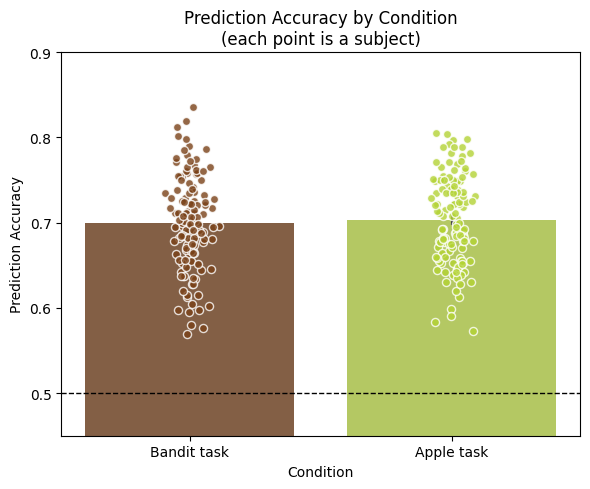

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Set matplotlib params for editable text in PDFs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Calculate prediction_accuracy per row
trials_df['prediction_accuracy'] = trials_df.apply(lambda x: np.mean(np.array(x.bmstate) == np.array(x.resp)), axis=1)
# Aggregate per subject/condition
prediction_accuracy = trials_df.groupby(['subj', 'cond']).prediction_accuracy.mean().reset_index()

# Define colors
bandit_color = "#794118"
apple_color = "#B3D334"
cond_colors = [bandit_color, apple_color]

plt.figure(figsize=(6,5))

# Draw barplot (one bar per condition, no dodge)
bar = sns.barplot(
    data=prediction_accuracy,
    x='cond',
    y='prediction_accuracy',
    estimator=np.mean,
    errorbar='se',
    palette=cond_colors,
    zorder=1,
    alpha=0.85
)

# Overlay subject-level scatter per condition
for cond, color in zip([0,1], cond_colors):
    x_loc = cond
    acc = prediction_accuracy.loc[prediction_accuracy['cond'] == cond, 'prediction_accuracy']
    x_jitter = np.random.normal(x_loc, 0.04, size=len(acc))
    plt.scatter(
        x_jitter,
        acc,
        color=color,
        edgecolor='w',
        alpha=0.8,
        zorder=2,
        s=34
    )

bar.set_xticks([0, 1])
bar.set_xticklabels(['Bandit task', 'Apple task'])
bar.set_xlabel('Condition')
bar.set_ylabel('Prediction Accuracy')
plt.title('Prediction Accuracy by Condition\n(each point is a subject)')

# Set y-axis limits and draw dashed line at 0.5
plt.ylim(0.45, 0.9)
plt.gca().set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
plt.axhline(0.5, color='k', linestyle='--', lw=1)

plt.tight_layout()
#plt.savefig("figures/prediction_accuracy_by_condition_janv2026.pdf")
plt.show()

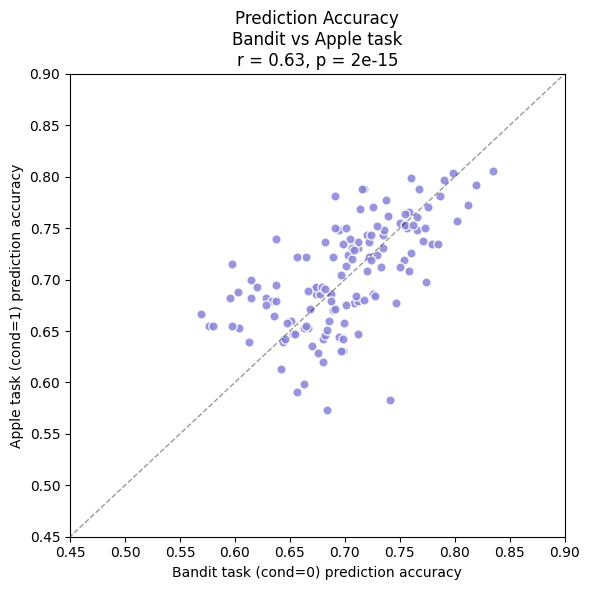

In [15]:
# Plot bandit task (cond=0) vs apple task (cond=1) prediction accuracy as scatter, add correlation

# Extract prediction accuracy for both conditions per subject
bandit_acc = prediction_accuracy.loc[prediction_accuracy['cond'] == 0, 'prediction_accuracy'].reset_index(drop=True)
apple_acc = prediction_accuracy.loc[prediction_accuracy['cond'] == 1, 'prediction_accuracy'].reset_index(drop=True)

plt.figure(figsize=(6,6))
plt.scatter(bandit_acc, apple_acc, color="#8884d8", alpha=0.86, s=44, edgecolor="w")
plt.xlabel("Bandit task (cond=0) prediction accuracy")
plt.ylabel("Apple task (cond=1) prediction accuracy")

# Calculate Pearson correlation
from scipy.stats import pearsonr
corr, pval = pearsonr(bandit_acc, apple_acc)

# Plot correlation coefficient on figure
plt.title(f'Prediction Accuracy\nBandit vs Apple task\nr = {corr:.2f}, p = {pval:.1g}')
plt.plot([0.4, 0.9], [0.4, 0.9], color='k', linestyle='--', linewidth=1, alpha=0.4)  # diagonal

plt.xlim(0.45, 0.9)
plt.ylim(0.45, 0.9)
plt.tight_layout()
plt.show()

In [30]:
outlist = []
# Import here at top level, do not import 'fit_model' from ambiguous location

resample_agent = True
np.random.seed(0)

for i_subj, subject_id in enumerate(tqdm(trials_df.subj.unique())):

    self = Worker(
        SwitchingBandit(),
        "results/source/saved_models",
        "banditGRU_newinit_val_0_beta2_participant_id{0}".format(i_subj + 1),
    )

    self.load_model()
    for condition_index in [0, 1]:
        for sample in ["sample2", "sample2_retest"]:
            if resample_agent:

                self = Worker(
                    SwitchingBandit(),
                    "results/source/saved_models",
                    "banditGRU_newinit_val_0_beta2_participant_id{0}".format(np.random.randint(129) + 1),
                )
                self.load_model()

            _sampled_subject_id = np.random.choice(trials_df.subj.unique())
            subject_df = trials_df[(trials_df.subj == _sampled_subject_id) & (trials_df.cond == condition_index) & (trials_df.samp == sample)]
            subject_df = subject_df.assign(block_id=subject_df.trlnum.apply(lambda x: np.cumsum(np.array(x) == 1)))

            self.env.reset_to_participant_task(subject_df)
            self.env.nu = torch.from_numpy(np.array([h_opt[i_subj]] * self.env.n_trials))

            self.participant_params = {
                'alpha': trials_df[(trials_df.subj == subject_id) & (trials_df.cond == condition_index) & (trials_df.samp == sample)].alpha.iloc[0], 
                'omega': trials_df[(trials_df.subj == subject_id) & (trials_df.cond == condition_index) & (trials_df.samp == sample)].omega.iloc[0]
            }

            self.participant_params = None
            results = self.evaluate(use_ground_truth=False)
            
            # from fit_model import fit_model_inf_simple
            # fit_result_partial = fit_model_inf_simple(data_for_eval, fast_optim=True)

            outlist.append(
                [
                    subject_id, 
                    condition_index, 
                    h_opt[i_subj], 
                    subject_df.h.iloc[0], 
                    results['params_transition'].mean(axis=1).detach().numpy()[0], 
                    float(results['rewards'].mean()), 
                    list((results['actions'].squeeze() + 1).numpy()),
                    sample,
                ]
            )

100%|██████████| 129/129 [01:27<00:00,  1.48it/s]


In [31]:
outdf = pd.DataFrame(outlist, columns=['subject_id', 'condition_index', 'h_opt', 'params_h', 'params_transition', 'rewards', 'actions', 'sample'])
outdf.head()

,subject_id,condition_index,h_opt,params_h,params_transition,rewards,actions,sample
0,2,0,0.072327,0.411635,0.146549,0.068542,"[1.0, 1.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 2.0, ...",sample2
1,2,0,0.072327,0.421109,0.178807,0.086944,"[1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",sample2_retest
2,2,1,0.072327,0.254558,0.235349,0.065556,"[1.0, 1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 2.0, ...",sample2
3,2,1,0.072327,0.079935,0.201863,0.098333,"[1.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...",sample2_retest
4,5,0,0.099962,0.247385,0.178919,0.117361,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",sample2


In [32]:
spearmanr(outdf.h_opt.values, outdf.params_transition.values)

SignificanceResult(statistic=-0.028445470409501416, pvalue=0.5191084606610747)

In [33]:
from scipy.stats import spearmanr
spearmanr(
    outdf[(outdf.condition_index == 1)].params_transition.values,
    outdf[(outdf.condition_index == 0)].params_transition.values,
)

SignificanceResult(statistic=-0.020224945217119088, pvalue=0.746455679317886)

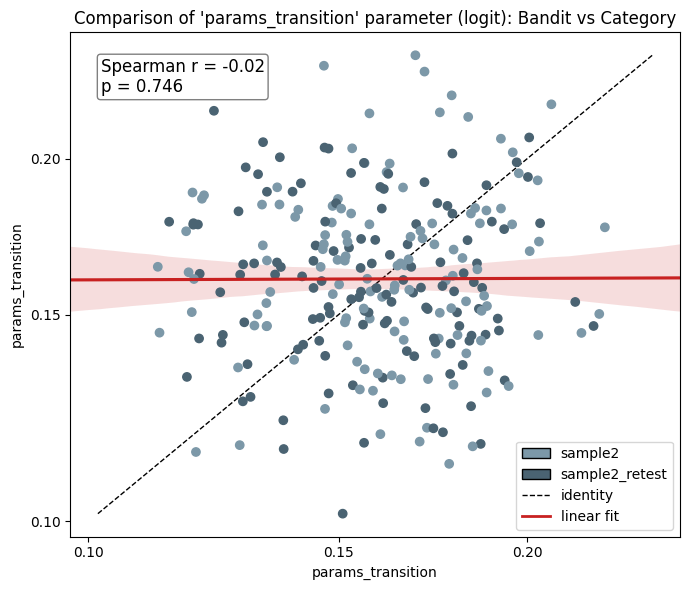

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logit
from matplotlib.patches import Patch

col_name = "params_transition"
# Convert 'params_transition' to plain float for seaborn compatibility
result_df_plot = outdf.copy()
result_df_plot["params_transition"] = result_df_plot[col_name].apply(
    lambda x: float(x) if hasattr(x, '__getitem__') and not isinstance(x, str) else x
)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# --- Scatter plot and regression line: params_transition (bandit vs category), axes in logit space ---

# Extract 'params_transition' values for bandit and category, align by subject
params_bandit = outdf[outdf.condition_index == 0][col_name].astype(float).reset_index(drop=True)
params_category = outdf[outdf.condition_index == 1][col_name].astype(float).reset_index(drop=True)

sample_values = outdf[outdf.condition_index == 0]['sample'].values
colors = np.where(sample_values == "sample2", "#7C98A8", "#4A6372")

params_bandit_logit = logit(params_bandit)
params_category_logit = logit(params_category)

# Scatter plot points
ax.scatter(params_bandit_logit, params_category_logit, c=colors, zorder=2)

# Add seaborn regplot (regression line with CI) - zorder is not supported!
ax.set_xlabel('logit(params_transition; bandit)')
ax.set_ylabel('logit(params_transition; category)')
ax.set_title("Comparison of 'params_transition' parameter (logit): Bandit vs Category")

# Plot identity line
min_val = min(params_bandit_logit.min(), params_category_logit.min())
max_val = max(params_bandit_logit.max(), params_category_logit.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='identity', zorder=1)

# Calculate and annotate Spearman correlation
from scipy.stats import spearmanr
rho_pt, pval_pt = spearmanr(params_bandit_logit, params_category_logit)
ax.annotate(f"Spearman r = {rho_pt:.2f}\np = {pval_pt:.3g}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=1))

# Add legend for identity line and color mapping
legend_elements = [
    Patch(facecolor="#7C98A8", edgecolor='k', label='sample2'),
    Patch(facecolor="#4A6372", edgecolor='k', label='sample2_retest'),
    plt.Line2D([0], [0], color='k', lw=1, linestyle='--', label='identity'),
    plt.Line2D([0], [0], color='#C82121', lw=2, label='linear fit'),
]
ax.legend(handles=legend_elements)

# Set x-ticks at native_vol (true volatilities, non-logit values) but label at their values, placed at their logit transformation
vol_axis = [0.1, 0.15, 0.2, 0.3]
xtick_positions = logit(vol_axis)
xtick_labels = [f"{v:.2f}" for v in vol_axis]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ytick_positions = logit(vol_axis)
ytick_labels = [f"{v:.2f}" for v in vol_axis]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)

sns.regplot(x=params_bandit_logit, y=params_category_logit, ax=ax, scatter=False, line_kws={'color':'#C82121'}, ci=95, truncate=False)

plt.tight_layout()
plt.savefig(f"figures/params_transition_bandit_vs_category_logit_feb2026_with_resampling_{resample_agent}.pdf")
plt.show()

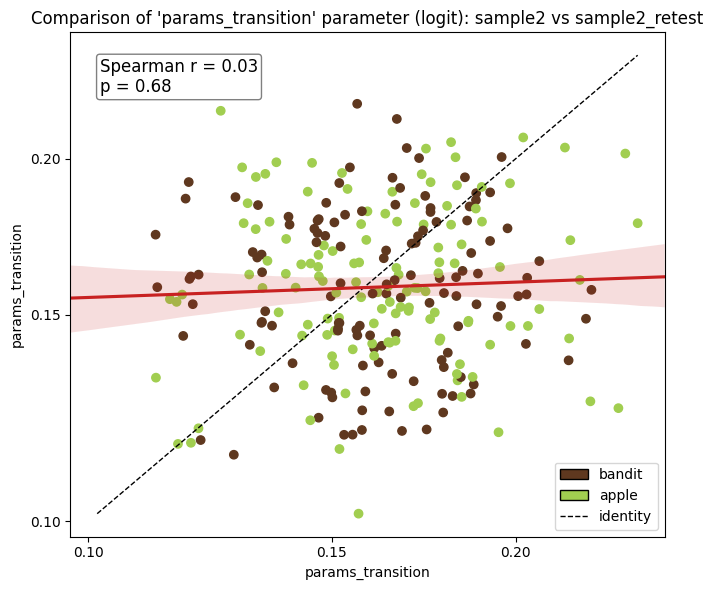

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logit
from matplotlib.patches import Patch

col_name = "params_transition"
# Convert 'params_transition' to plain float for seaborn compatibility
result_df_plot = outdf.copy()
result_df_plot["params_transition"] = result_df_plot[col_name].apply(
    lambda x: float(x) if hasattr(x, '__getitem__') and not isinstance(x, str) else x
)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# --- Only scatter plot: params_transition (bandit vs category), axes in logit space ---

# Extract 'params_transition' values for bandit and category
params_sample = outdf[outdf['sample'] == "sample2"][col_name].astype(float)
params_retest = outdf[outdf['sample'] == "sample2_retest"][col_name].astype(float)
import numpy as np

sample_values = outdf[outdf['sample'] == "sample2"]['condition_index'].values
colors = np.where(sample_values == 0, "#5F381F", "#A1CE50")

params_sample_logit = logit(params_sample)
params_retest_logit = logit(params_retest)

scatter = ax.scatter(params_sample_logit, params_retest_logit, c=colors)
ax.set_xlabel('logit(params_transition; sample2)')
ax.set_ylabel('logit(params_transition; sample2_retest)')
ax.set_title("Comparison of 'params_transition' parameter (logit): sample2 vs sample2_retest")
# Plot identity line
min_val = min(params_sample_logit.min(), params_retest_logit.min())
max_val = max(params_sample_logit.max(), params_retest_logit.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='identity')
# Calculate and annotate Spearman correlation
from scipy.stats import spearmanr
rho_pt, pval_pt = spearmanr(params_sample_logit, params_retest_logit)
ax.annotate(f"Spearman r = {rho_pt:.2f}\np = {pval_pt:.3g}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=1))

# Add legend for identity line and color mapping
legend_elements = [
    Patch(facecolor="#5F381F", edgecolor='k', label='bandit'),
    Patch(facecolor="#A1CE50", edgecolor='k', label='apple'),
    plt.Line2D([0], [0], color='k', lw=1, linestyle='--', label='identity')
]
ax.legend(handles=legend_elements)

# Set x-ticks at native_vol (true volatilities, non-logit values) but label at their values, placed at their logit transformation
vol_axis = [0.1, 0.15, 0.2, 0.3]
xtick_positions = logit(vol_axis)
xtick_labels = [f"{v:.2f}" for v in vol_axis]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

# Set y-ticks at logit(nus_learned_clipped) for native_vol values, with labels as their original unclipped values
# We'll use the mean or median of each y cluster as y-ticks to avoid crowding, or just use the grid of possible native volatilities
ytick_positions = logit(vol_axis)
ytick_labels = [f"{v:.2f}" for v in vol_axis]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)

plt.tight_layout()

sns.regplot(x=params_sample_logit, y=params_retest_logit, ax=ax, scatter=False, line_kws={'color':'#C82121'}, ci=95, truncate=False)

#plt.savefig("figures/params_transition_test_retest_logit_janv2026.pdf")
plt.show()

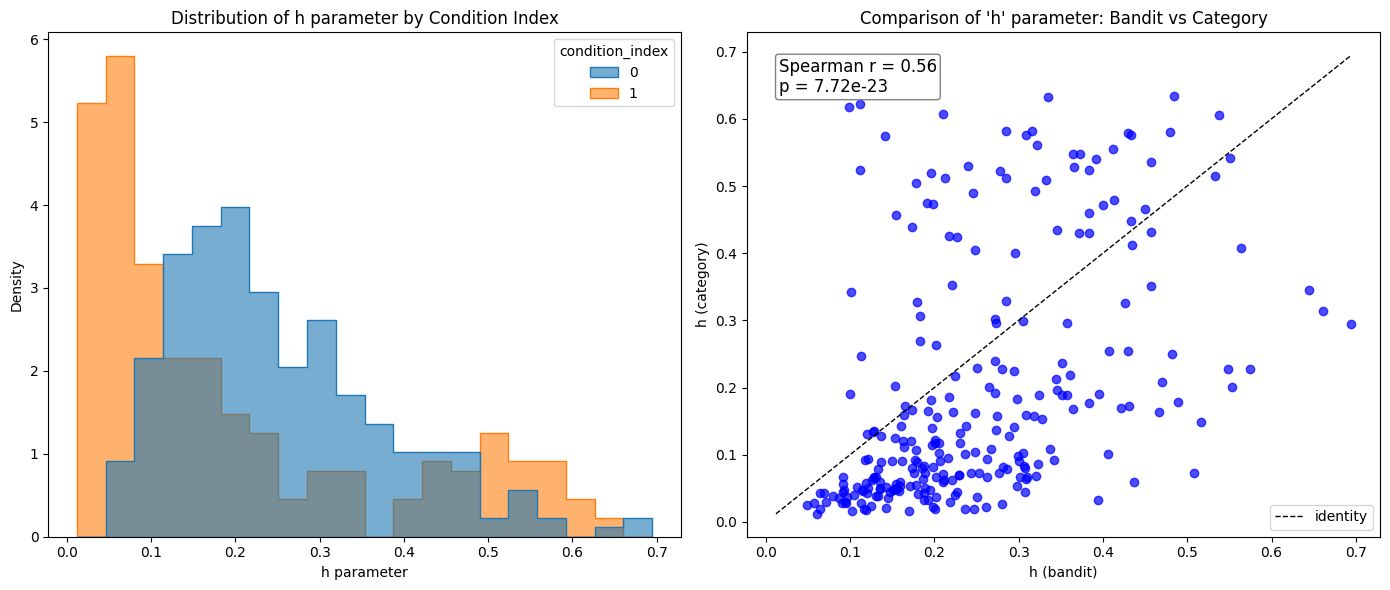

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Convert 'params_h' to plain float for seaborn compatibility
result_df_plot = outdf.copy()
result_df_plot["params_h"] = result_df_plot["params_h"].apply(
    lambda x: float(x) if hasattr(x, '__getitem__') and not isinstance(x, str) else x
)

# Prepare bandit/category data for shared subjects/scatter
if "subject_id" in outdf.columns:
    df_bandit = outdf[outdf.condition_index == 0][["subject_id", "params_h"]].set_index("subject_id")
    df_category = outdf[outdf.condition_index == 1][["subject_id", "params_h"]].set_index("subject_id")
    shared_subjects = df_bandit.index.intersection(df_category.index)
    h_bandit = df_bandit.loc[shared_subjects, "params_h"].values
    h_category = df_category.loc[shared_subjects, "params_h"].values
else:
    # fallback: just align/hard match order (not robust, but will not error)
    h_bandit = outdf[outdf.condition_index == 0]["params_h"].values
    h_category = outdf[outdf.condition_index == 1]["params_h"].values
    min_len = min(len(h_bandit), len(h_category))
    h_bandit = h_bandit[:min_len]
    h_category = h_category[:min_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- First subplot: Histogram of h by condition ---
sns.histplot(
    data=result_df_plot, 
    x="params_h", 
    hue="condition_index", 
    bins=20, 
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Distribution of h parameter by Condition Index")
axes[0].set_xlabel("h parameter")
axes[0].set_ylabel("Density")

# --- Second subplot: Scatter of h: bandit vs category ---
axes[1].scatter(h_bandit, h_category, c='blue', alpha=0.7)
axes[1].set_xlabel('h (bandit)')
axes[1].set_ylabel('h (category)')
axes[1].set_title("Comparison of 'h' parameter: Bandit vs Category")
# Plot identity line
min_val = min(h_bandit.min(), h_category.min())
max_val = max(h_bandit.max(), h_category.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='identity')
# Calculate and annotate Spearman correlation
rho_h, pval_h = spearmanr(h_bandit, h_category)
axes[1].annotate(f"Spearman r = {rho_h:.2f}\np = {pval_h:.3g}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=1))
axes[1].legend()

plt.tight_layout()
plt.show()

### Systematic deviations

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_15623/3350878275.py:14: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  norm_factor = trapz(p_gen_unnormalized, x)


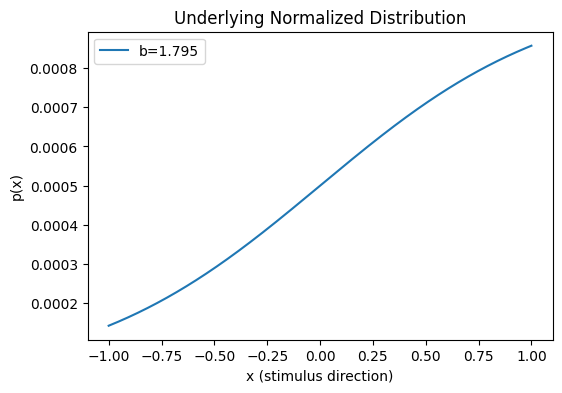

In [81]:
import numpy as np
from scipy.integrate import trapz
from scipy.optimize import brentq
import matplotlib.pyplot as plt

perr = 0.3
x = np.arange(-1, 1.001, 0.001)

efac = 1.795391

# Plot the underlying (normalized) distribution
b = efac
p_gen_unnormalized = 1/(1+np.exp(x*b))
norm_factor = trapz(p_gen_unnormalized, x)
p_gen = p_gen_unnormalized / norm_factor
p_gen = p_gen[::-1] / p_gen[::-1].sum()

plt.figure(figsize=(6,4))
plt.plot(x, p_gen, label=f'b={b:.3f}')
plt.title("Underlying Normalized Distribution")
plt.xlabel("x (stimulus direction)")
plt.ylabel("p(x)")
plt.legend()
plt.show()

In [82]:
np.sum(p_gen * x)

0.26010933195877894

In [84]:
p_gen[x < 0].sum()

0.30017085539036026

In [85]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.03, 0.07, 0.13, 0.2, 0.3]
range_of_ffs = [0.3]
range_of_mus = [0.26]

nb_tasks = 1000
vols_grid, ffs_grid, mus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_mus, indexing='ij')
vols, ffs, mus = vols_grid.ravel(), ffs_grid.ravel(), mus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]
mus = np.tile(mus, nb_repeats)[:nb_tasks]

nb_bins_volatility = len(range_of_vols)
nb_bins_falsefeedback = len(range_of_ffs)

In [94]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 129
nb_trials = 1000

# volatility
nus_native = np.zeros([nb_simul, nb_bins_volatility])
nus_learned = np.zeros([nb_simul, nb_bins_volatility])

for index in tqdm(range(1, nb_simul + 1)):

    self = Worker(
        SwitchingBandit(n_trials=nb_trials),
        "results/source/saved_models",
        "banditGRU_newinit_val_0_beta2_participant_id{0}".format(index),
    )

    self.load_model(nb_episodes=50000)

    np.random.seed(0)
    torch.manual_seed(0)
    self.env.reset(nb_tasks=nb_tasks, nus=vols, ffs=ffs, mus=mus)
    result = self.evaluate(use_ground_truth=False)

    # volatility
    nus = self.env.nu.mean(axis=1)
    sorted_bins = np.array([0] + range_of_vols) + 1e-9
    digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
    digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped
    for bin in range(nb_bins_volatility):
        nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
        nus_learned[index - 1, bin] = result["params_transition"][digited_bins == bin][:, -1].mean().detach().numpy()

100%|██████████| 129/129 [12:14<00:00,  5.69s/it]


In [117]:
np.array(np.linspace(0, 129, 10), dtype=int)

array([  0,  14,  28,  43,  57,  71,  86, 100, 114, 129])

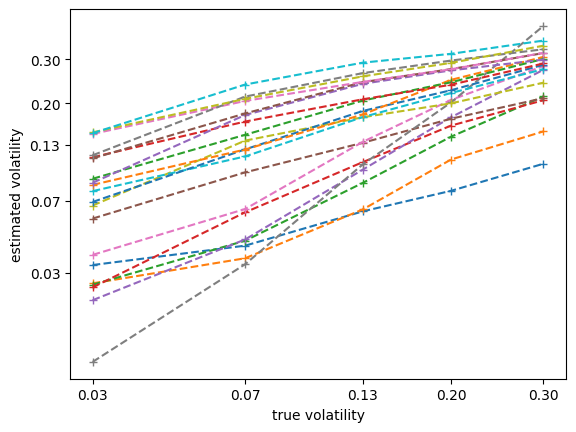

In [126]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from scipy.special import logit, expit

arg_sorted = np.argsort(nus_learned.mean(axis=1))
selected_indexes = arg_sorted[np.array(np.linspace(10, 120, 20), dtype=int) - 1]

native_vol = nus_native[0]
# To ensure we don't have values exactly 0 or 1, clip to avoid domain errors
eps = 1e-6
native_vol_clipped = np.clip(native_vol, eps, 1 - eps)
nus_learned_clipped = np.clip(nus_learned[selected_indexes], eps, 1 - eps)

fig, ax = plt.subplots()
for i in range(len(selected_indexes)):    
    ax.plot(logit(native_vol_clipped), logit(nus_learned_clipped[i]), '--+')

# Set x-ticks at native_vol (true volatilities, non-logit values) but label at their values, placed at their logit transformation
xtick_positions = logit(native_vol_clipped)
xtick_labels = [f"{v:.2f}" for v in native_vol]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('true volatility')

# Set y-ticks at logit(nus_learned_clipped) for native_vol values, with labels as their original unclipped values
# We'll use the mean or median of each y cluster as y-ticks to avoid crowding, or just use the grid of possible native volatilities
ytick_positions = logit(native_vol_clipped)
ytick_labels = [f"{v:.2f}" for v in native_vol]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)
#ax.set_ylim([-3.9, -0.2])
ax.set_ylabel('estimated volatility')
plt.savefig("figures/inferred_volatility_vs_true_volatility_janv2026.pdf")


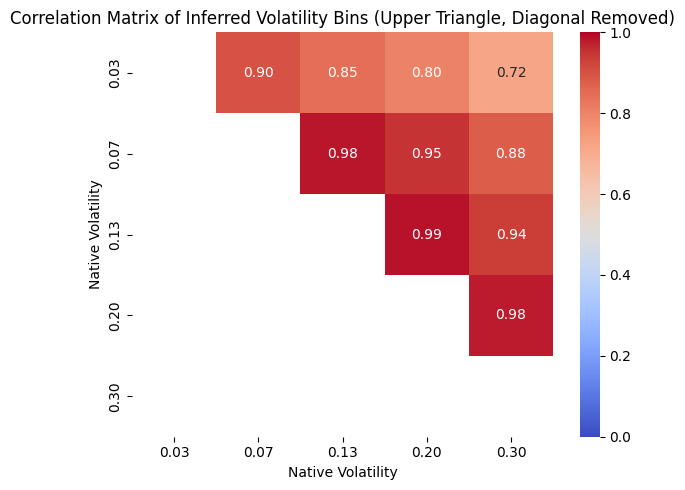

In [127]:
import seaborn as sns

# Compute correlation matrix across learned volatility bins (columns)
corr_matrix = np.corrcoef(nus_learned.T)

# Mask lower triangle and diagonal; only upper triangle strictly above diagonal
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=0)

plt.figure(figsize=(6,5))
# Ensure colorbar starts at 0
vmin = 0
vmax = 1
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
    xticklabels=[f"{v:.2f}" for v in native_vol], 
    yticklabels=[f"{v:.2f}" for v in native_vol], 
    mask=mask, vmin=vmin, vmax=vmax
)
plt.title("Correlation Matrix of Inferred Volatility Bins (Upper Triangle, Diagonal Removed)")
plt.xlabel("Native Volatility")
plt.ylabel("Native Volatility")
plt.tight_layout()
plt.savefig("figures/correlation_matrix_inferred_volatility_janv2026.pdf")
plt.show()

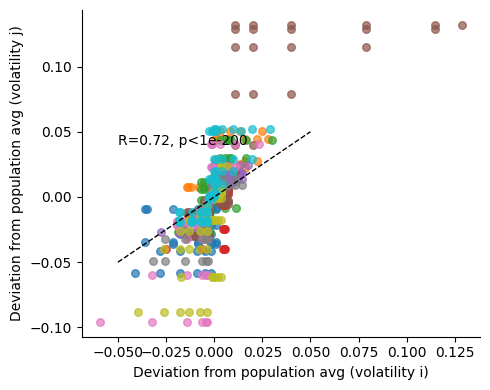

In [33]:
import itertools
from scipy.stats import pearsonr
plt.figure(figsize=(5, 4))
nb_agents, nb_volatilities = nus_learned.shape
colors = plt.cm.tab10(np.linspace(0, 1, nb_agents))

# For each agent, plot all pairs of inferred volatilities (no replacement, unordered)
all_pairs = []
for agent in range(nb_agents):
    agent_vols = nus_learned[agent]
    pairs = list(itertools.combinations(range(nb_volatilities), 2))
    x = [agent_vols[i] - nus_learned[:, i].mean() for i, j in pairs]
    y = [agent_vols[j] - nus_learned[:, j].mean() for i, j in pairs]
    plt.scatter(x, y, color=colors[agent], label=f'Agent {agent+1}', alpha=0.7, s=30)
    all_pairs.append([x, y])

all_pairs = np.array(all_pairs)
# Add x==y curve
lims = [-0.05, 0.05]
plt.plot(lims, lims, 'k--', linewidth=1, label='x = y')
#plt.gca().set_xlim(lims)
#plt.gca().set_ylim(lims)

plt.xlabel('Deviation from population avg (volatility i)')
plt.ylabel('Deviation from population avg (volatility j)')
plt.gca().spines[['top', 'right']].set_visible(False)
#plt.gca().set_yticks([-0.01, -0.005, 0, 0.005, 0.01])
#plt.gca().set_xticks([-0.01, -0.005, 0, 0.005, 0.01])
#plt.ylim([-0.012, 0.012])
#plt.legend(title='Agent', loc='lower right', fontsize='small', ncol=2)
all_pairs = np.reshape(np.swapaxes(all_pairs, 1, 2), (-1, 2))
from scipy.stats import pearsonr, spearmanr
R, p = pearsonr(all_pairs[:, 0], all_pairs[:, 1])

plt.text(-0.05, 0.04, f"R={np.round(R, 2)}, p<1e-200")
plt.tight_layout()
plt.savefig("figures/deviation_from_mean_inferred_volatility_dec2025.pdf")
plt.show()

### STABLE vs VOLATILE

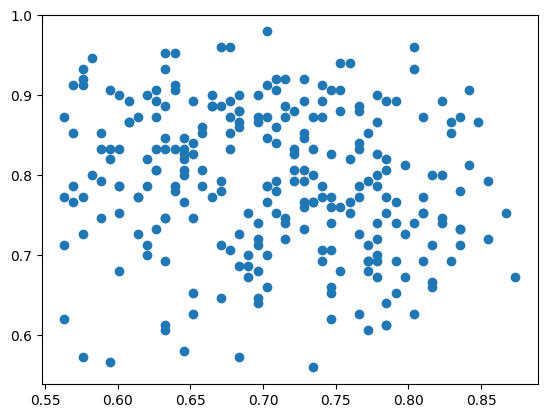

In [62]:
volatile_performance, stable_performance = pcorr_sub_all.T

from scipy.stats import pearsonr
spearmanr(volatile_performance, stable_performance)

plt.scatter(volatile_performance, stable_performance)


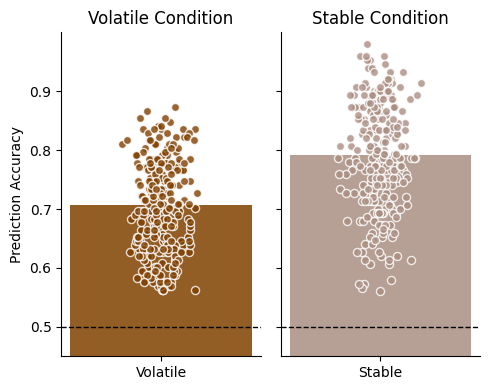

In [61]:
# Plot subject-wise prediction accuracies: bar plots for volatile and stable side by side using subplots
np.random.seed(0)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib

# Set matplotlib params for editable text in PDFs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

nb_subj = len(volatile_performance)

# Colors for each condition
volatile_color = np.array([0.5, 0.25, 0])
stable_color = np.array([170, 142, 130]) / 255

# Prepare statistics
mean_volatile = np.mean(volatile_performance)
se_volatile = np.std(volatile_performance) / np.sqrt(nb_subj)
mean_stable = np.mean(stable_performance)
se_stable = np.std(stable_performance) / np.sqrt(nb_subj)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 4), sharey=True)

# --- Volatile subplot ---
ax = axes[0]
ax.bar(0, mean_volatile, yerr=se_volatile, color=volatile_color, alpha=0.85, zorder=1, width=0.6)
x_jitter = np.random.normal(0, 0.05, size=nb_subj)
ax.scatter(x_jitter, volatile_performance, color=volatile_color, edgecolor='w', alpha=0.8, s=34, zorder=2)
ax.set_xlabel('')
ax.set_ylabel('Prediction Accuracy')
ax.set_title('Volatile Condition')
ax.set_xticks([0])
ax.set_xticklabels(['Volatile'])
ax.set_ylim(0.45, 1.)
ax.axhline(0.5, color='k', linestyle='--', lw=1)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
# REMOVE TOP AND RIGHT EDGES
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Stable subplot ---
ax = axes[1]
ax.bar(0, mean_stable, yerr=se_stable, color=stable_color, alpha=0.85, zorder=1, width=0.6)
x_jitter = np.random.normal(0, 0.05, size=nb_subj)
ax.scatter(x_jitter, stable_performance, color=stable_color, edgecolor='w', alpha=0.8, s=34, zorder=2)
ax.set_xlabel('')
ax.set_ylabel('')  # No y-label for right plot
ax.set_title('Stable Condition')
ax.set_xticks([0])
ax.set_xticklabels(['Stable'])
ax.set_ylim(0.45, 1.)
ax.axhline(0.5, color='k', linestyle='--', lw=1)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
# REMOVE TOP AND RIGHT EDGES
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/prediction_accuracy_volatile_vs_stable_subplots.pdf")
plt.show()

## Debug script

In [ ]:
from data.load_and_process_data import convert_mat_to_dataframe
from fit_model import calculate_negative_log_likelihood
import numpy as np

trials_df = convert_mat_to_dataframe()

subj_id = trials_df.subj.unique()[10]

subject_df = trials_df[(trials_df.subj == subj_id) * (trials_df.cond == 1) * (trials_df.samp == 'sample2')]

data_for_eval = {
    'trlnum': np.array(subject_df.trlnum.iloc[0]),
    'stim': np.array(subject_df.stim.iloc[0]),
    'resp': np.array(subject_df.resp.iloc[0]),
    'rprv': np.array(subject_df.rprv.iloc[0]),
    'cond': 1
}

# 3. Define the exact parameter values from the MATLAB fit
matlab_params = {
    'tau': subject_df.tau.iloc[0],
    'alpha': subject_df.alpha.iloc[0],
    'omega': subject_df.omega.iloc[0],
    'h': subject_df.h.iloc[0]
}

# 4. Call the imported function and print the result
neg_log_likelihood = calculate_negative_log_likelihood(matlab_params, data_for_eval)

print(f"Negative Log-Likelihood at MATLAB parameters: {neg_log_likelihood}")

from fit_model import fit_model_inf_simple

fit_result_partial = fit_model_inf_simple(data_for_eval, alpha=subject_df.alpha.iloc[0], omega=subject_df.omega.iloc[0])

print('fit result in python:')
print(fit_result_partial)

print('ground truth parameters - fit in matlab:')
for attribut in ['alpha', 'omega', 'tau', 'h']:
    print(attribut, subject_df[attribut].iloc[0])